In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import r2_score
from scipy.stats import pearsonr, spearmanr
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


In [10]:
_cost = {
    "localdiffdock": 407.5, "diffdock": 407.5, "flexx": 3.33, "smina": 99.9,
    "gnina": 105.8, "plants": 6.85, "cnnscore": 0.31, "cnnaffinity": 0.31,
    "smina_affinity": 0.31, "ad4": 0.28, "linf9": 0.24, "rtmscore": 0.41,
    "vinardo": 0.29, "scorch": 4.63, "hyde": 2.0, "chemplp": 0.121,
    "rfscore_v1": 0.682, "rfscore_v2": 0.687, "rfscore_v3": 0.69,
    "vina_hydrophobic": 0.69, "vina_intra_hydrophobic": 0.69,
}

print("Loading and Aggregating Data...")
df_orig = pd.read_csv("all_rescoring_results_merged.csv")

agg_rules = {
    'CNNscore': 'max', 'CNNaffinity': 'max', 'smina_affinity': 'max',
    'RTMScore': 'max', 'SCORCH': 'max', 'HYDE': 'max', 'rfscore_v2': 'max',
    'CHEMPLP': 'min', 'vina_hydrophobic': 'min', 'vina_intra_hydrophobic': 'min',
    'true_value': 'first', 'activity_class': 'first'
}

for col in df_orig.select_dtypes(include=np.number).columns:
    if col not in agg_rules and col not in ["pose", "id", "true_value", "activity_class"]:
        agg_rules[col] = "mean"

df_agg = df_orig.groupby(["id","docking_tool"]).agg(agg_rules).reset_index()

meta_cols = ["true_value", "activity_class"]
score_cols = [c for c in df_agg.columns if c not in meta_cols and c not in ["id","docking_tool"]]
wide = df_agg.set_index(["id", "docking_tool"])[score_cols].unstack("docking_tool")
wide.columns = [f"{tool}_{score}" for score, tool in wide.columns]
meta = df_agg.groupby("id")[meta_cols].first()
df_matrix = wide.join(meta)

df_matrix

Loading and Aggregating Data...


,diffdock_CNNscore,flexx_CNNscore,gnina_CNNscore,plants_CNNscore,smina_CNNscore,diffdock_CNNaffinity,flexx_CNNaffinity,gnina_CNNaffinity,plants_CNNaffinity,smina_CNNaffinity,...,gnina_vina_hydrophobic,plants_vina_hydrophobic,smina_vina_hydrophobic,diffdock_vina_intra_hydrophobic,flexx_vina_intra_hydrophobic,gnina_vina_intra_hydrophobic,plants_vina_intra_hydrophobic,smina_vina_intra_hydrophobic,true_value,activity_class
id,,,,,,,,,,,,,,,,,,,,,
CHEMBL107472,0.230358,0.318374,0.704503,0.845547,0.704503,6.062439,6.330606,6.770721,6.856157,6.770721,...,17.040275,11.281798,12.811730,15.424397,14.392877,13.122920,13.801589,13.769564,5.124939,0
CHEMBL1090364,0.753230,0.459508,0.648672,0.085986,0.648672,8.145165,7.744378,8.244999,7.844476,8.086423,...,33.329206,46.584723,35.004347,17.199321,11.857168,10.846852,18.751411,10.846852,8.193820,1
CHEMBL1095464,NaN,0.221300,0.949931,0.441181,0.949931,NaN,6.349084,7.639035,7.255926,7.639035,...,40.377515,34.069408,40.377515,NaN,15.048121,13.751400,19.417773,13.751400,5.040959,0
CHEMBL1097189,0.299841,0.733825,0.841830,0.811187,0.841830,6.579234,7.683257,7.730244,7.670531,7.730244,...,51.521676,59.248934,51.521676,23.898682,39.983632,26.721804,37.518372,26.721804,5.602060,0
CHEMBL1172773,0.113217,0.049243,0.592747,0.601510,0.593319,6.965350,6.588732,7.554906,7.454876,7.557323,...,55.350394,57.858481,47.827333,40.425779,42.480121,35.049914,33.861991,32.076141,7.086186,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHEMBL7819,0.317333,0.552823,0.818149,0.798095,0.818149,5.896833,6.073943,6.436514,6.395360,6.436514,...,32.888089,31.902450,28.105821,9.504977,8.492893,8.704411,8.681227,8.685322,6.769551,0
CHEMBL7866,0.484698,0.612489,0.917534,0.849771,0.917534,6.512511,6.415994,6.857832,6.744023,6.857832,...,26.546878,27.433593,26.546878,9.510094,8.346990,8.686770,8.681995,8.686770,7.193820,0
CHEMBL80540,0.286375,0.438205,0.840270,0.359730,0.840270,6.106951,6.671166,7.850224,7.350696,7.850224,...,34.297352,30.289108,45.067768,12.714972,9.648312,9.131143,9.301261,9.120654,8.522879,1


In [15]:
df_matrix.columns

Index(['diffdock_CNNscore', 'flexx_CNNscore', 'gnina_CNNscore',
       'plants_CNNscore', 'smina_CNNscore', 'diffdock_CNNaffinity',
       'flexx_CNNaffinity', 'gnina_CNNaffinity', 'plants_CNNaffinity',
       'smina_CNNaffinity', 'diffdock_smina_affinity', 'flexx_smina_affinity',
       'gnina_smina_affinity', 'plants_smina_affinity', 'smina_smina_affinity',
       'diffdock_RTMScore', 'flexx_RTMScore', 'gnina_RTMScore',
       'plants_RTMScore', 'smina_RTMScore', 'diffdock_SCORCH', 'flexx_SCORCH',
       'gnina_SCORCH', 'plants_SCORCH', 'smina_SCORCH', 'diffdock_HYDE',
       'flexx_HYDE', 'gnina_HYDE', 'plants_HYDE', 'smina_HYDE',
       'diffdock_rfscore_v2', 'flexx_rfscore_v2', 'gnina_rfscore_v2',
       'plants_rfscore_v2', 'smina_rfscore_v2', 'diffdock_CHEMPLP',
       'flexx_CHEMPLP', 'gnina_CHEMPLP', 'plants_CHEMPLP', 'smina_CHEMPLP',
       'diffdock_vina_hydrophobic', 'flexx_vina_hydrophobic',
       'gnina_vina_hydrophobic', 'plants_vina_hydrophobic',
       'smina_vina_hyd

In [14]:
feature_costs = {}
for col in df_matrix.columns:
    if col in ['true_value', 'activity_class']:
        continue
    
    # Split the column name into tool and score
    # e.g., 'diffdock_CNNscore' -> 'diffdock' and 'CNNscore'
    parts = col.split('_', 1) 
    if len(parts) == 2:
        tool, score = parts[0], parts[1].lower()
        # Sum the cost of the tool and the scoring function
        total_cost = _cost.get(tool, 0) + _cost.get(score, 0)
        feature_costs[col] = total_cost

feature_costs

{'diffdock_CNNscore': 407.81,
 'flexx_CNNscore': 3.64,
 'gnina_CNNscore': 106.11,
 'plants_CNNscore': 7.159999999999999,
 'smina_CNNscore': 100.21000000000001,
 'diffdock_CNNaffinity': 407.81,
 'flexx_CNNaffinity': 3.64,
 'gnina_CNNaffinity': 106.11,
 'plants_CNNaffinity': 7.159999999999999,
 'smina_CNNaffinity': 100.21000000000001,
 'diffdock_smina_affinity': 407.81,
 'flexx_smina_affinity': 3.64,
 'gnina_smina_affinity': 106.11,
 'plants_smina_affinity': 7.159999999999999,
 'smina_smina_affinity': 100.21000000000001,
 'diffdock_RTMScore': 407.91,
 'flexx_RTMScore': 3.74,
 'gnina_RTMScore': 106.21,
 'plants_RTMScore': 7.26,
 'smina_RTMScore': 100.31,
 'diffdock_SCORCH': 412.13,
 'flexx_SCORCH': 7.96,
 'gnina_SCORCH': 110.42999999999999,
 'plants_SCORCH': 11.48,
 'smina_SCORCH': 104.53,
 'diffdock_HYDE': 409.5,
 'flexx_HYDE': 5.33,
 'gnina_HYDE': 107.8,
 'plants_HYDE': 8.85,
 'smina_HYDE': 101.9,
 'diffdock_rfscore_v2': 408.187,
 'flexx_rfscore_v2': 4.017,
 'gnina_rfscore_v2': 106.487,

In [3]:
# Tool Cost Helpers
def get_base_tool(col_name):
    return col_name.split('_')[0].lower()

def calculate_tool_family_cost(base_tool, active_features):
    cost = _cost.get(base_tool, 0.0)
    rescorers = set([f.split('_', 1)[1].lower() for f in active_features if len(f.split('_', 1)) > 1 and f.startswith(base_tool)])
    for r in rescorers:
        cost += _cost.get(r, 0.0)
    return cost if cost > 0 else 1.0


RUNNING PIPELINE: Imputation: DROP | Scaler: StandardScaler


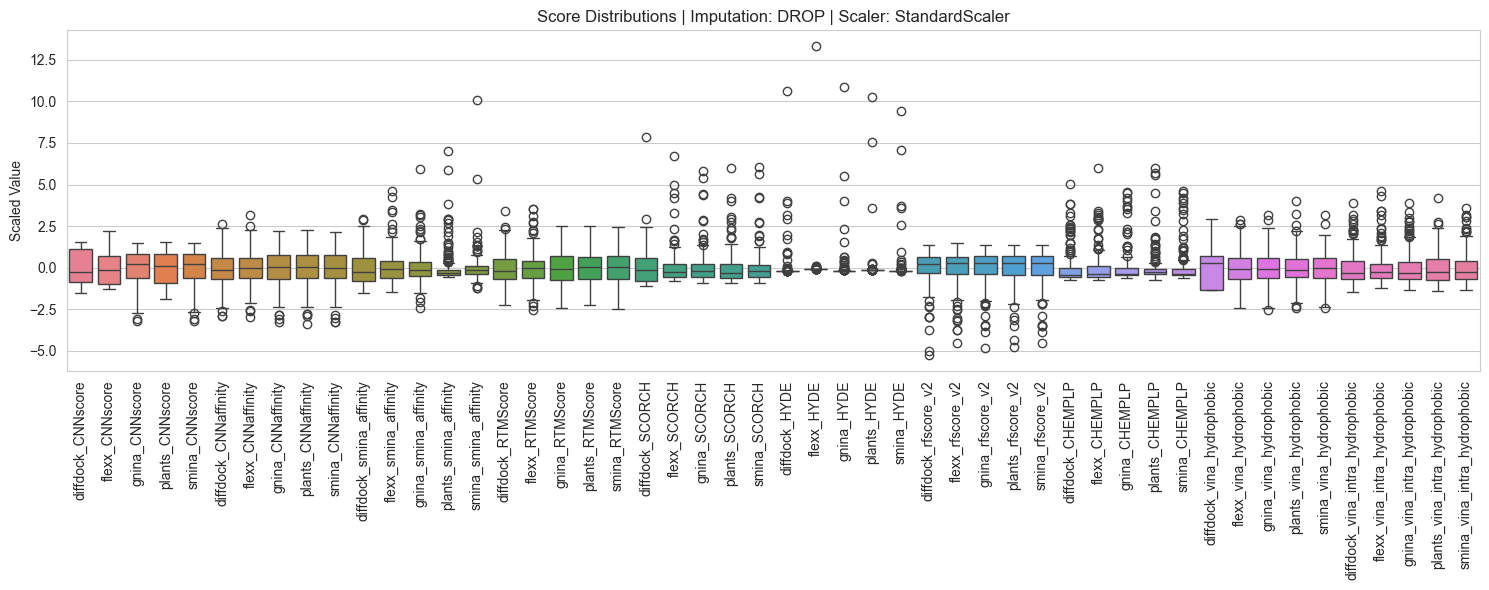

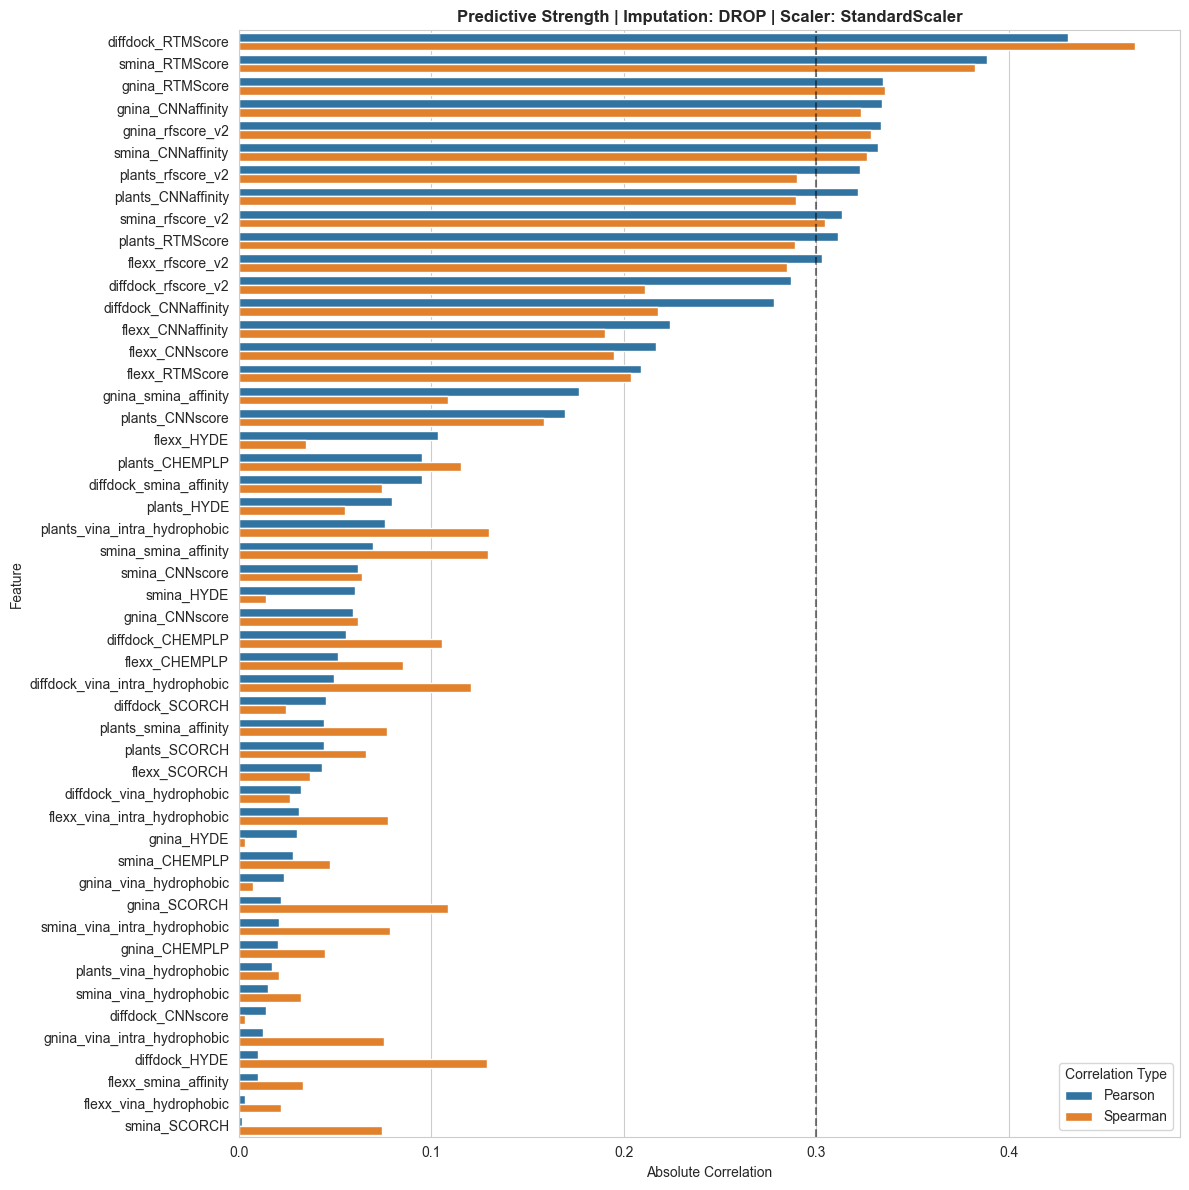

🚀 EXECUTING BRUTE-FORCE PARETO SEARCH (ALL 31 COMBINATIONS)...

🏆 FLAWLESS PARETO TRADEOFF TABLE (EVALUATED ON TEST SET)
 Tools_Left  Total_Cost  Test_Pearson  Test_R2_Score                Pipeline
          3     550.624      0.662645       0.427976 plants, diffdock, gnina
          3     544.724      0.639758       0.403849 smina, plants, diffdock
          2     431.146      0.639342       0.398527         flexx, diffdock
          1     417.658      0.605202       0.340611                diffdock
          2     132.966      0.280330       0.054254           plants, gnina
          2     127.066      0.271075       0.034267           smina, plants
          1     110.058      0.278200       0.025668                   smina
          1      17.008      0.162965      -0.154949                  plants
          1      13.488     -0.059364      -0.326016                   flexx

RUNNING PIPELINE: Imputation: MEAN | Scaler: MinMaxScaler


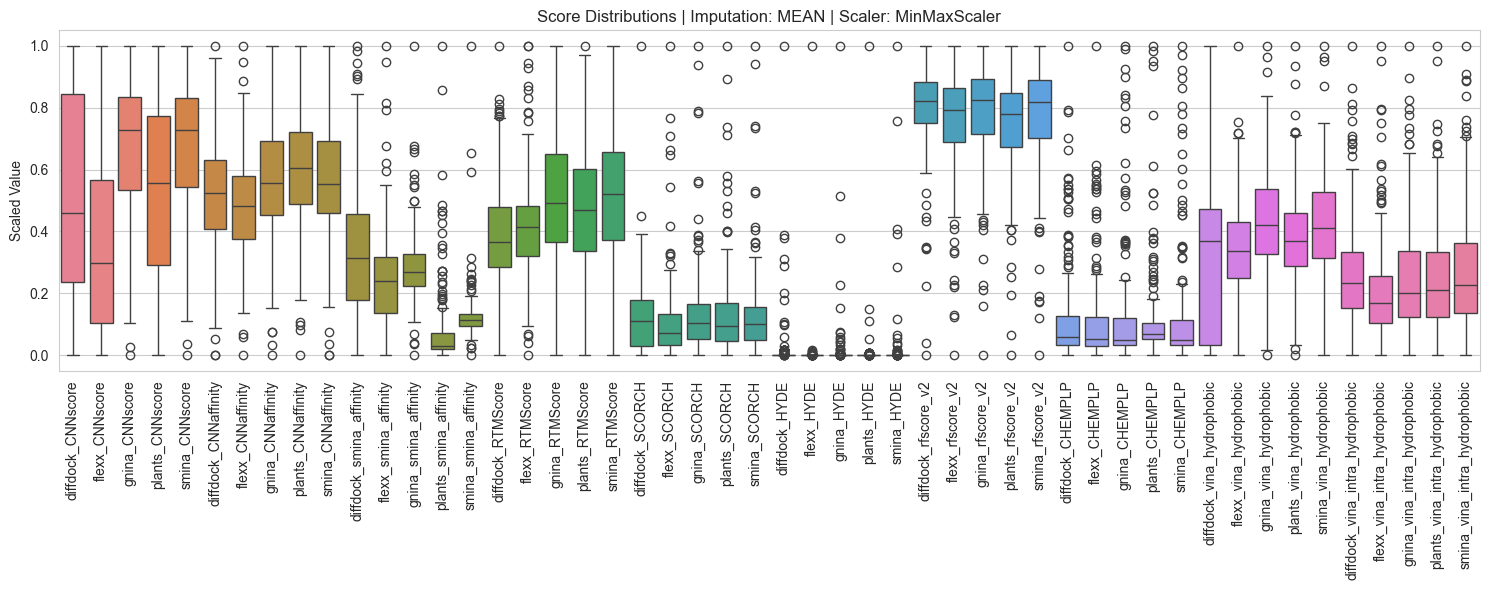

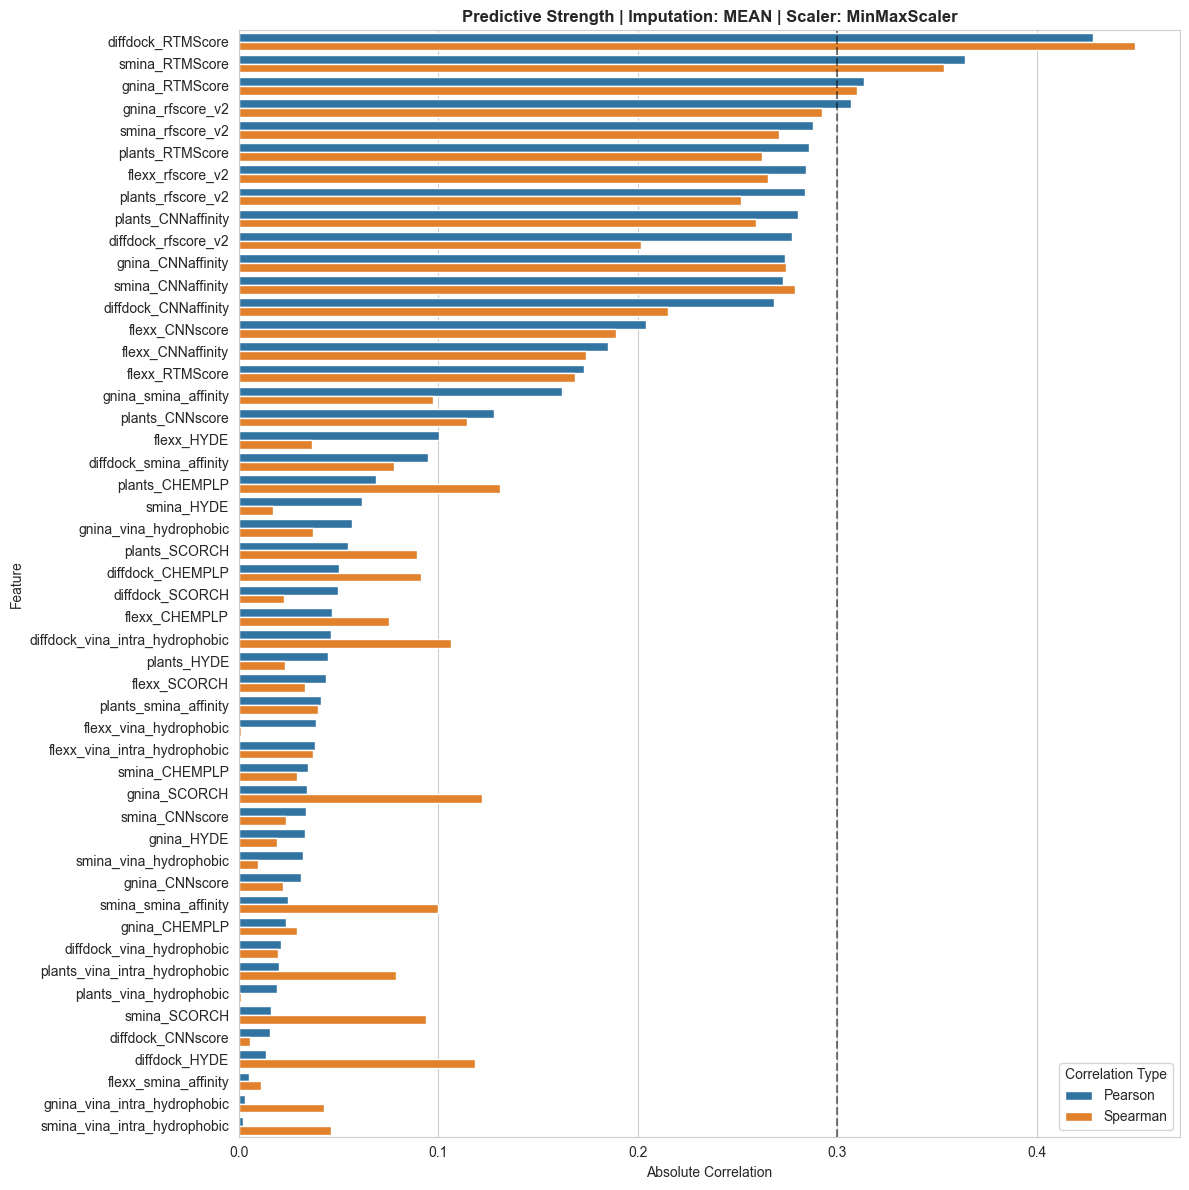

🚀 EXECUTING BRUTE-FORCE PARETO SEARCH (ALL 31 COMBINATIONS)...

🏆 FLAWLESS PARETO TRADEOFF TABLE (EVALUATED ON TEST SET)
 Tools_Left  Total_Cost  Test_Pearson  Test_R2_Score      Pipeline
          2     226.016      0.626391       0.343371  smina, gnina
          1     110.058      0.598821       0.320592         smina
          2      30.496      0.267984      -0.153611 flexx, plants
          1      17.008      0.257136      -0.154177        plants
          1      13.488      0.144357      -0.252304         flexx

RUNNING PIPELINE: Imputation: MAX | Scaler: RobustScaler


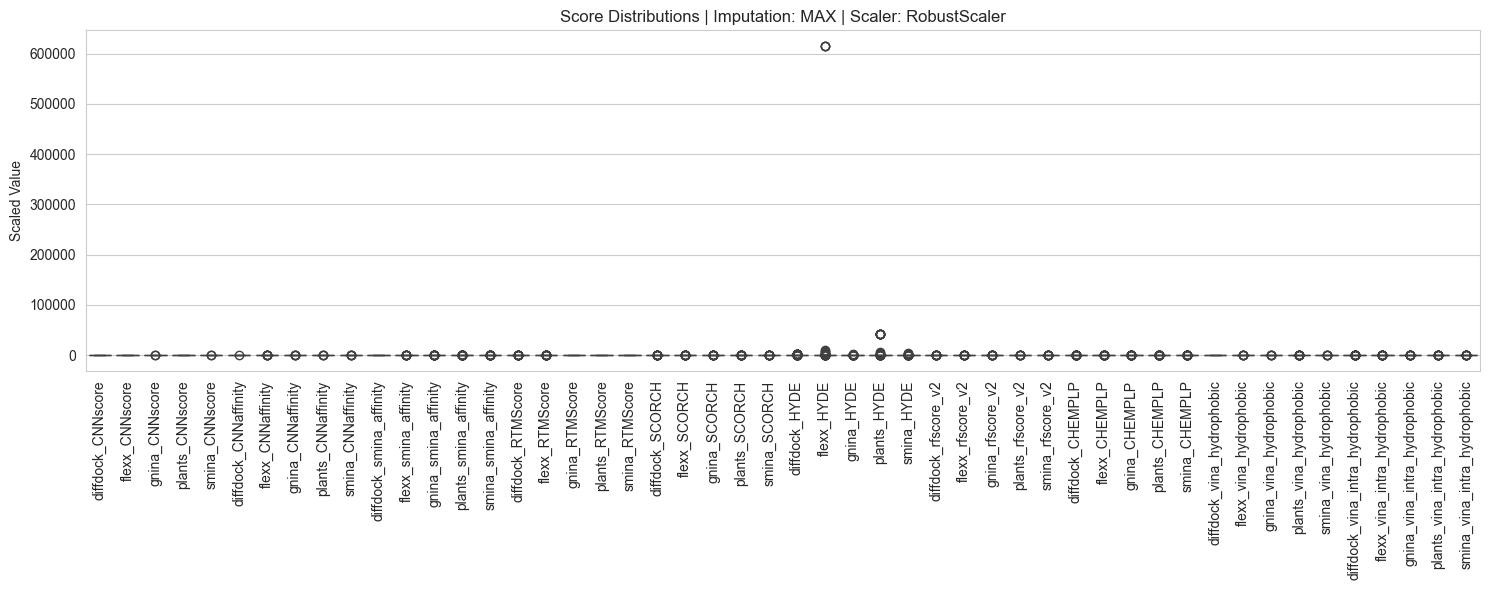

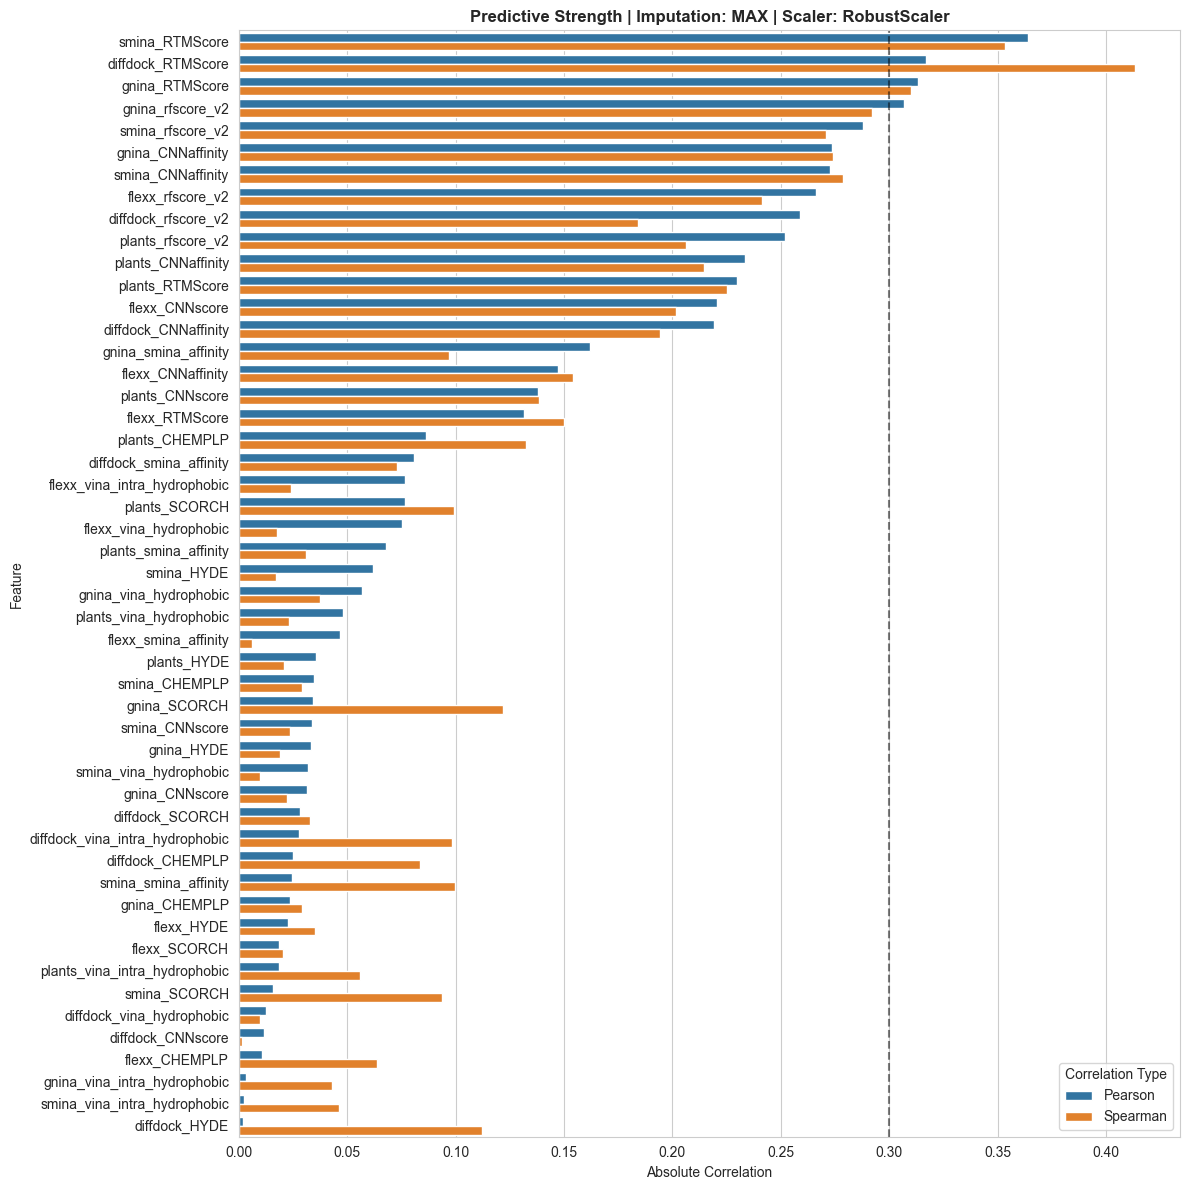

🚀 EXECUTING BRUTE-FORCE PARETO SEARCH (ALL 31 COMBINATIONS)...

🏆 FLAWLESS PARETO TRADEOFF TABLE (EVALUATED ON TEST SET)
 Tools_Left  Total_Cost  Test_Pearson  Test_R2_Score     Pipeline
          2     226.016      0.630623       0.357987 smina, gnina
          1     110.058      0.611310       0.327169        smina
          1      17.008      0.320908      -0.051777       plants
          1      13.488      0.194366      -0.225059        flexx

RUNNING PIPELINE: Imputation: MIN | Scaler: RobustScaler


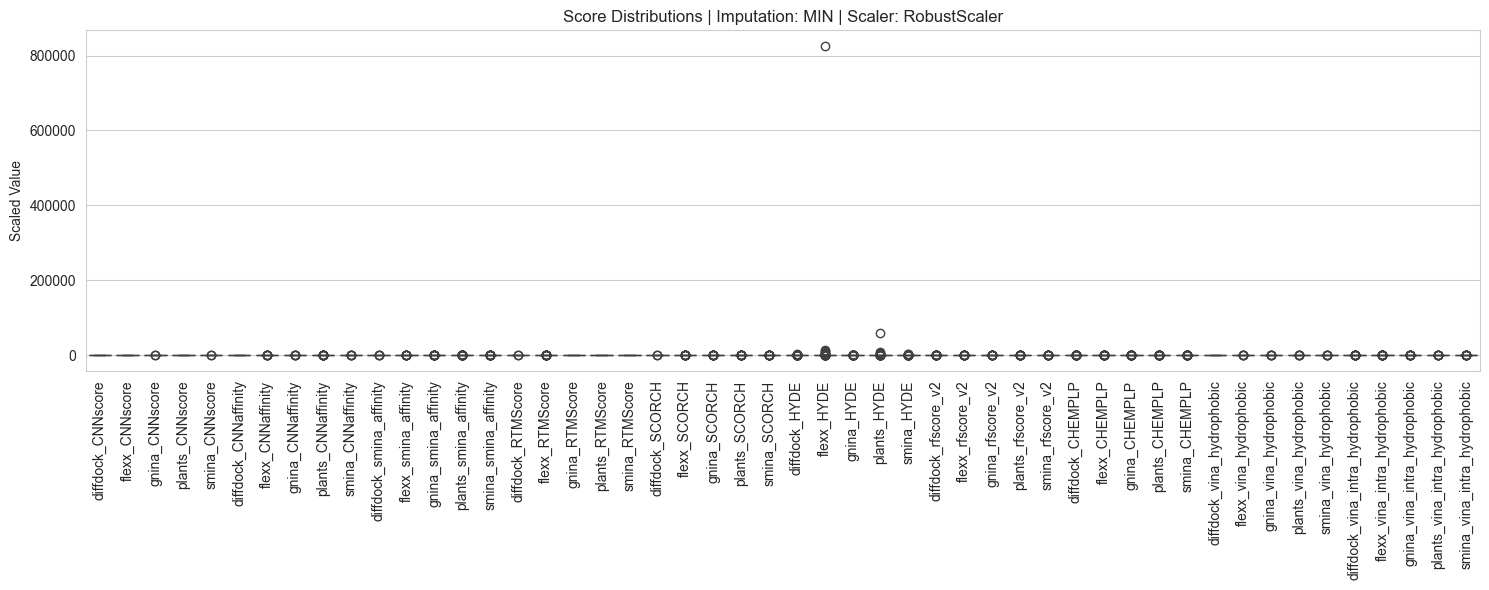

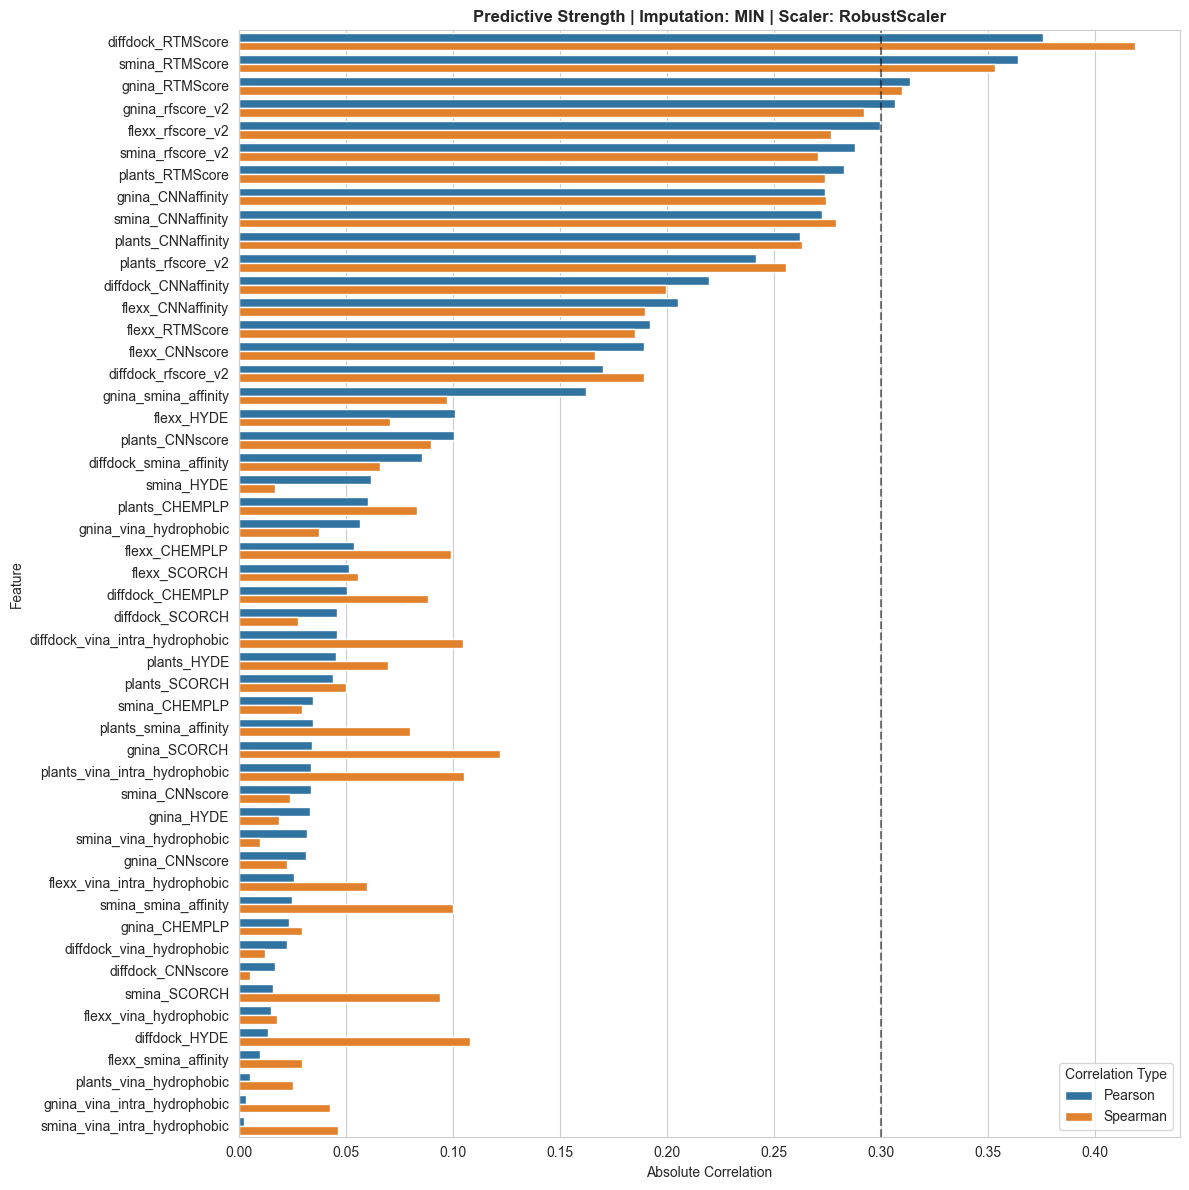

🚀 EXECUTING BRUTE-FORCE PARETO SEARCH (ALL 31 COMBINATIONS)...

🏆 FLAWLESS PARETO TRADEOFF TABLE (EVALUATED ON TEST SET)
 Tools_Left  Total_Cost  Test_Pearson  Test_R2_Score     Pipeline
          2     226.016      0.630623       0.357987 smina, gnina
          1     110.058      0.611310       0.327169        smina
          1      17.008      0.302236      -0.054341       plants
          1      13.488      0.242063      -0.133166        flexx


In [ ]:
import itertools

def run_experiment(impute_method, scaler_type):
    config_name = f"Imputation: {impute_method.upper()} | Scaler: {scaler_type.__name__}"
    print(f"\n{'='*80}")
    print(f"RUNNING PIPELINE: {config_name}")
    print(f"{'='*80}")

    df_temp = df_matrix.copy()
    feature_cols = [c for c in df_temp.columns if c not in meta_cols]

    # --- 1. DATA PREPARATION ---
    if impute_method == 'drop':
        df_temp = df_temp.dropna()
    elif impute_method == 'mean':
        df_temp[feature_cols] = df_temp[feature_cols].fillna(df_temp[feature_cols].mean())
        df_temp = df_temp.dropna(subset=['true_value'])
    elif impute_method == 'max': 
        df_temp[feature_cols] = df_temp[feature_cols].fillna(df_temp[feature_cols].max())
        df_temp = df_temp.dropna(subset=['true_value'])
    elif impute_method == 'min': 
        df_temp[feature_cols] = df_temp[feature_cols].fillna(df_temp[feature_cols].min())
        df_temp = df_temp.dropna(subset=['true_value'])

    # --- 2. VISUALIZATIONS ---
    df_vis = df_temp.copy()
    
    # if scaler_type.__name__ != 'RobustScaler':
    #     for col in feature_cols:
    #         lower = df_vis[col].quantile(0.01)
    #         upper = df_vis[col].quantile(0.99)
    #         df_vis[col] = df_vis[col].clip(lower=lower, upper=upper)
            
    temp_scaler = scaler_type()
    df_vis[feature_cols] = temp_scaler.fit_transform(df_vis[feature_cols])

    plt.figure(figsize=(15, 6))
    sns.boxplot(data=df_vis[feature_cols])
    plt.xticks(rotation=90)
    plt.title(f"Score Distributions | {config_name}")
    plt.ylabel("Scaled Value")
    plt.tight_layout()
    plt.show()

    corr_data = []
    for col in feature_cols:
        p_corr, _ = pearsonr(df_temp[col], df_temp['true_value'])
        s_corr, _ = spearmanr(df_temp[col], df_temp['true_value'])
        corr_data.append({'Feature': col, 'Pearson': abs(p_corr), 'Spearman': abs(s_corr)})

    df_corr = pd.DataFrame(corr_data).sort_values(by='Pearson', ascending=False)
    df_melted = df_corr.melt(id_vars='Feature', var_name='Correlation Type', value_name='Absolute Correlation')

    plt.figure(figsize=(12, 12))
    sns.barplot(data=df_melted, y='Feature', x='Absolute Correlation', hue='Correlation Type') 
    plt.title(f"Predictive Strength | {config_name}", fontweight='bold')
    plt.axvline(x=0.3, color='black', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # --- 3. STRICT MACHINE LEARNING SPLIT (RESTORED TO STRESS TEST SPLIT) ---
    X = df_temp[feature_cols]
    y = df_temp['true_value']
    
    # 80/20 Split (Exactly the same as your Stress Test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

    if scaler_type.__name__ != 'RobustScaler':
        for col in feature_cols:
            lower = X_train[col].quantile(0.01)
            upper = X_train[col].quantile(0.99)
            X_train[col] = X_train[col].clip(lower=lower, upper=upper)
            X_test[col] = X_test[col].clip(lower=lower, upper=upper)

    ml_scaler = scaler_type()
    X_train_scaled = pd.DataFrame(ml_scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
    X_test_scaled = pd.DataFrame(ml_scaler.transform(X_test), columns=feature_cols, index=X_test.index)

    # --- 4. FLAWLESS EXHAUSTIVE SUBSET SEARCH ---
    print(f"🚀 EXECUTING BRUTE-FORCE PARETO SEARCH (ALL 31 COMBINATIONS)...")
    
    import itertools
    all_base_tools = list(set([get_base_tool(f) for f in feature_cols]))
    all_combinations = []
    for i in range(1, len(all_base_tools) + 1):
        all_combinations.extend(itertools.combinations(all_base_tools, i))
        
    results = []
    
    for combo in all_combinations:
        combo_tools = list(combo)
        active_features = [f for f in feature_cols if get_base_tool(f) in combo_tools]
        total_cost = sum([calculate_tool_family_cost(t, active_features) for t in combo_tools])
        
        model = xgb.XGBRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=6, 
            subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
        )
        model.fit(X_train_scaled[active_features], y_train)
        
        # Evaluate on the exact same X_test as the Stress Test
        test_pred = model.predict(X_test_scaled[active_features])
        test_r2 = r2_score(y_test, test_pred)
        test_pearson, _ = pearsonr(y_test, test_pred)
        
        results.append({
            'Tools_Left': len(combo_tools),
            'Total_Cost': total_cost,
            'Test_Pearson': test_pearson,
            'Test_R2_Score': test_r2,
            'Pipeline': ", ".join(combo_tools)
        })
        
    # --- 5. EXTRACT THE TRUE PARETO FRONTIER ---
    df_results = pd.DataFrame(results).sort_values(by='Total_Cost', ascending=True)
    pareto_frontier = []
    max_r2_seen = -float('inf')
    
    for _, row in df_results.iterrows():
        if row['Test_R2_Score'] > max_r2_seen:
            pareto_frontier.append(row)
            max_r2_seen = row['Test_R2_Score']
            
    df_pareto = pd.DataFrame(pareto_frontier).sort_values(by='Total_Cost', ascending=False)
    
    print("\n🏆 FLAWLESS PARETO TRADEOFF TABLE (EVALUATED ON TEST SET)")
    print(df_pareto[['Tools_Left', 'Total_Cost', 'Test_Pearson', 'Test_R2_Score', 'Pipeline']].to_string(index=False))

# --- EXECUTE THE EXPERIMENTS ---
experiments = [
    ('drop', StandardScaler),
    ('mean', MinMaxScaler),
    ('max', RobustScaler),
    ('min', RobustScaler) 
]

for impute, scaler in experiments:
    run_experiment(impute, scaler)


🚀 INITIATING FINAL XGBOOST ABLATION PIPELINE
[1/3] Splitting and Preprocessing Data...
[2/3] Executing Cost-Aware Backward Ablation Loop (This takes 1-2 minutes)...

[3/3] Analysis Complete.
🏆 FINAL PARETO TRADEOFF FRONTIER 🏆
 Tools_Left  Total_Cost  Pearson_r  R2_Score      Dropped_Next
          5     674.170   0.534526  0.281614             gnina
          4     558.212   0.552903  0.303207            plants
          3     541.204   0.556293  0.308907             flexx
          2     527.716   0.563802  0.311162             smina
          1     417.658   0.599303  0.350115 None (Final Tool)


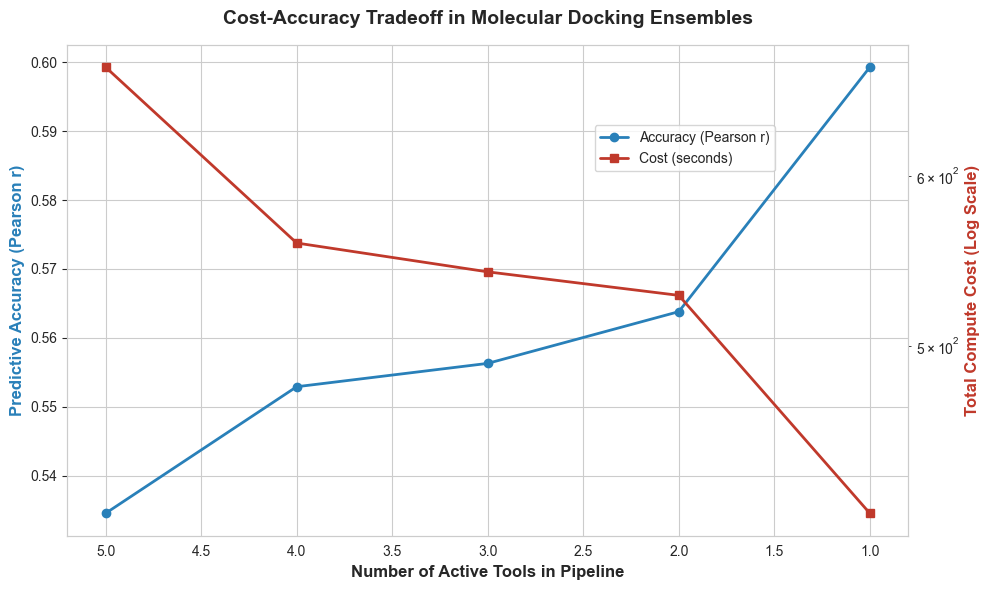

In [ ]:
# %%
# ==========================================
# FINAL SECTION: TRUE ABLATION PIPELINE
# ==========================================
print("\n" + "="*60)
print("🚀 INITIATING FINAL XGBOOST ABLATION PIPELINE")
print("="*60)

df_clean = df_matrix.dropna().copy()
feature_cols = [c for c in df_clean.columns if c not in meta_cols]

X = df_clean[feature_cols].copy()
y = df_clean['true_value'].copy()

print("[1/3] Splitting and Preprocessing Data...")
# 1. Split off a true, untouched TEST set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# 2. Split the rest into TRAIN and VALIDATION (for the ablation loop)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

scaler = RobustScaler()
X_train[feature_cols] = pd.DataFrame(scaler.fit_transform(X_train[feature_cols]), columns=feature_cols, index=X_train.index)
X_val[feature_cols] = pd.DataFrame(scaler.transform(X_val[feature_cols]), columns=feature_cols, index=X_val.index)       # Fixed: Val is now scaled
X_test[feature_cols] = pd.DataFrame(scaler.transform(X_test[feature_cols]), columns=feature_cols, index=X_test.index)    # Fixed: Test is now scaled

print("[2/3] Executing Cost-Aware Backward Ablation Loop (This takes 1-2 minutes)...")

current_features = list(feature_cols)
history = []

while len(current_features) > 0:
    active_tools = list(set([get_base_tool(f) for f in current_features]))
    current_cost = sum([calculate_tool_family_cost(t, current_features) for t in active_tools])
    
    # 1. Train Baseline Model (with all currently active tools)
    baseline_model = xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6, 
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    )
    baseline_model.fit(X_train[current_features], y_train)
    baseline_pred = baseline_model.predict(X_val[current_features])  
    baseline_r2 = r2_score(y_val, baseline_pred)                       
    baseline_pearson, _ = pearsonr(y_val, baseline_pred)               
    
    if len(active_tools) <= 1:
        history.append({
            'Tools_Left': len(active_tools),
            'Total_Cost': current_cost,
            'Pearson_r': baseline_pearson,
            'R2_Score': baseline_r2,
            'Dropped_Next': "None (Final Tool)",
            'Pipeline': ", ".join(active_tools)
        })
        break
        
    # 2. Ablation Testing (Test dropping each tool one by one)
    ablation_scores = []
    
    for tool in active_tools:
        temp_features = [f for f in current_features if get_base_tool(f) != tool]
        
        temp_model = xgb.XGBRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=6, 
            subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
        )
        temp_model.fit(X_train[temp_features], y_train)
        temp_r2 = r2_score(y_val, temp_model.predict(X_val[temp_features])) 
        
        # Calculate the impact
        accuracy_loss = baseline_r2 - temp_r2
        cost_saved = calculate_tool_family_cost(tool, current_features)
        
        # Metric: Handle cases where removing noise IMPROVES accuracy
        if accuracy_loss < 0:
            loss_per_second_saved = accuracy_loss * cost_saved
        else:
            loss_per_second_saved = accuracy_loss / cost_saved
        
        ablation_scores.append((tool, loss_per_second_saved))
        
    # 3. Find the tool that hurts the least to drop
    ablation_scores.sort(key=lambda x: x[1])
    worst_tool = ablation_scores[0][0]
    
    # 4. Record the state BEFORE dropping the worst tool
    history.append({
        'Tools_Left': len(active_tools),
        'Total_Cost': current_cost,
        'Pearson_r': baseline_pearson,
        'R2_Score': baseline_r2,
        'Dropped_Next': worst_tool,
        'Pipeline': ", ".join(active_tools)
    })
    
    # 5. Permanently drop the worst tool
    current_features = [f for f in current_features if get_base_tool(f) != worst_tool]

df_history = pd.DataFrame(history)

print("\n[3/3] Analysis Complete.")
print("================================================================")
print("🏆 FINAL PARETO TRADEOFF FRONTIER 🏆")
print("================================================================")
print(df_history[['Tools_Left', 'Total_Cost', 'Pearson_r', 'R2_Score', 'Dropped_Next']].to_string(index=False))

# Plotting the Graph
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(df_history['Tools_Left'], df_history['Pearson_r'], color='#2980b9', marker='o', linewidth=2, label='Accuracy (Pearson r)')
ax2.plot(df_history['Tools_Left'], df_history['Total_Cost'], color='#c0392b', marker='s', linewidth=2, label='Cost (seconds)')

ax1.set_xlabel('Number of Active Tools in Pipeline', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predictive Accuracy (Pearson r)', color='#2980b9', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Compute Cost (Log Scale)', color='#c0392b', fontsize=12, fontweight='bold')
ax2.set_yscale('log')
ax1.invert_xaxis() 

plt.title("Cost-Accuracy Tradeoff in Molecular Docking Ensembles", fontsize=14, fontweight='bold', pad=15)
fig = plt.gcf()
fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.85), bbox_transform=ax1.transAxes)

plt.tight_layout()
plt.show()


🚀 INITIATING DOMAIN-GUIDED PIPELINE EVALUATION
Evaluating Logical Pipelines at Full Power...

🏆 TRUE PARETO TRADEOFF FRONTIER (TEST SET REALITY) 🏆
          Pipeline  Total_Cost  Test_Pearson   Test_R2
Exhaustive (All 5)     674.170      0.406334 -0.086456
  Gnina + DiffDock     533.616      0.392338 -0.041341
  Smina + DiffDock     527.716      0.435084  0.003988
 DiffDock + Plants     434.666      0.327466 -0.134907
  DiffDock + flexx     431.146      0.370130 -0.159215
          DiffDock     417.658      0.276599 -0.268190
     Smina + gnina     226.016      0.630623  0.357987
    Gnina + Plants     132.966      0.518033  0.212920
     Gnina + Flexx     129.446      0.466373  0.137694
    Smina + Plants     127.066      0.482651  0.124568
     Smina + Flexx     123.546      0.480866  0.180814
    flexx + Plants      30.496      0.294674 -0.126653


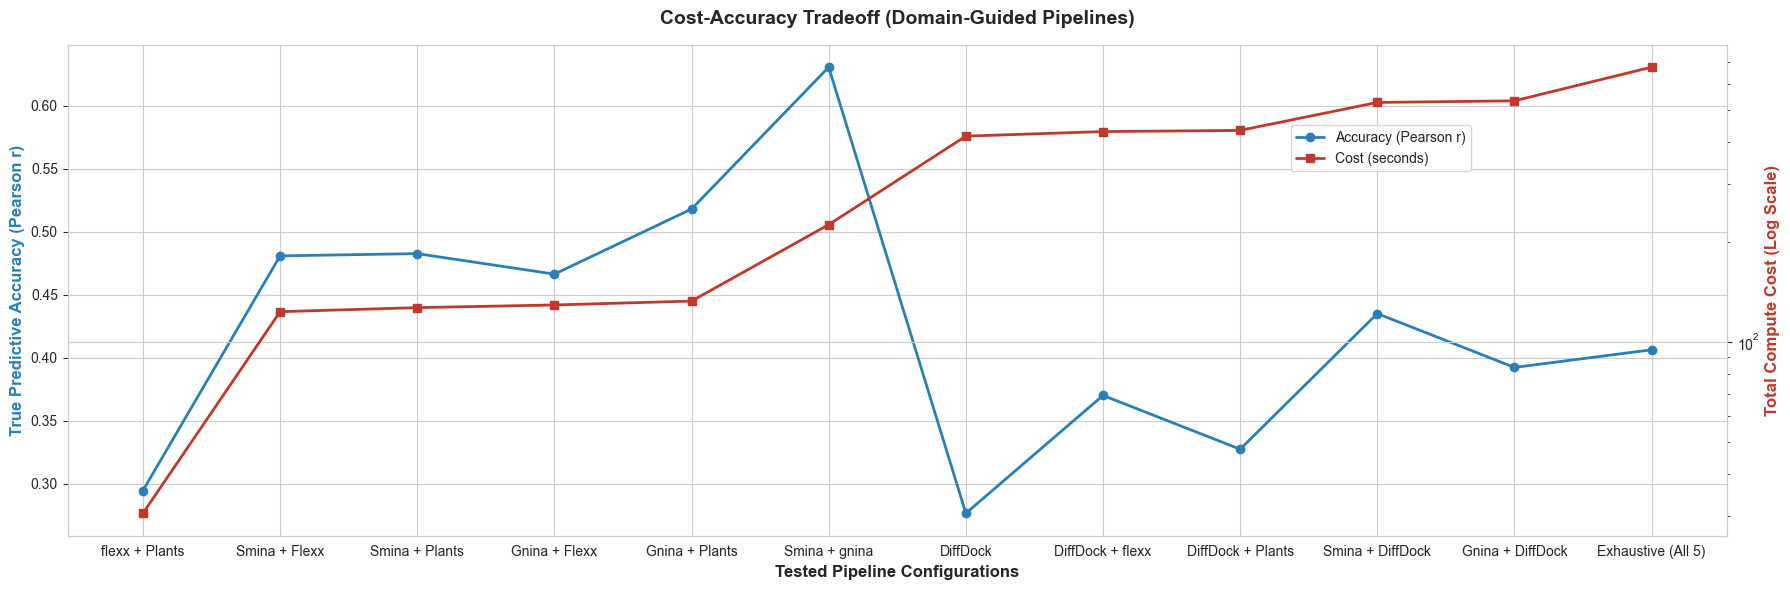

In [9]:
# ==========================================
# FINAL SECTION: DOMAIN-GUIDED PIPELINE EVALUATION
# ==========================================
print("\n" + "="*60)
print("🚀 INITIATING DOMAIN-GUIDED PIPELINE EVALUATION")
print("="*60)

df_clean = df_matrix.copy()

# Only impute the feature columns (don't accidentally impute the true_value target)
feature_cols = [c for c in df_clean.columns if c not in meta_cols]
df_clean[feature_cols] = df_clean[feature_cols].fillna(df_clean[feature_cols].max())

# Drop rows ONLY if the actual ground-truth target (true_value) is missing
df_clean = df_clean.dropna(subset=['true_value'])

X = df_clean[feature_cols].copy()
y = df_clean['true_value'].copy()

# 1. Single, clean Train/Test Split (80/20) - No more K-Fold starvation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Percentile Capping
# for col in feature_cols:
#     lower = X_train[col].quantile(0.01)
#     upper = X_train[col].quantile(0.99)
#     X_train[col] = X_train[col].clip(lower=lower, upper=upper)
#     X_test[col] = X_test[col].clip(lower=lower, upper=upper)

# Min-Max Normalization
scaler = RobustScaler()
X_train[feature_cols] = pd.DataFrame(scaler.fit_transform(X_train[feature_cols]), columns=feature_cols, index=X_train.index)
X_test[feature_cols] = pd.DataFrame(scaler.transform(X_test[feature_cols]), columns=feature_cols, index=X_test.index)

# 2. Define the Logical Pipelines based on Correlation & Redundancy EDA
pipelines_to_test = {
    "Exhaustive (All 5)": ["diffdock", "gnina", "smina", "plants", "flexx"],
    "DiffDock + Plants": ["diffdock", "plants"],
    "DiffDock + flexx": ["diffdock", "flexx"],    
    "flexx + Plants": ["flexx", "plants"],    


    "DiffDock": ["diffdock"], 

    "Gnina + Flexx": ["gnina", "flexx"],
    "Gnina + Plants": ["gnina", "plants"],
    "Gnina + DiffDock": ["gnina", "diffdock"],

    "Smina + Flexx": ["smina", "flexx"],                  
    "Smina + gnina": ["smina", "gnina"],
    "Smina + Plants":["smina", "plants"],  
    "Smina + DiffDock":["smina", "diffdock"],                


}

results = []

print("Evaluating Logical Pipelines at Full Power...\n")

for pipe_name, tools in pipelines_to_test.items():
    # Gather features and calculate exact cost
    active_features = [f for f in feature_cols if get_base_tool(f) in tools]
    total_cost = sum([calculate_tool_family_cost(t, active_features) for t in tools])
    
    # Train at Absolute Full Power
    model = xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6, 
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    )
    model.fit(X_train[active_features], y_train)
    
    # Predict on the True Test Set
    test_pred = model.predict(X_test[active_features])
    test_r2 = r2_score(y_test, test_pred)
    test_pearson, _ = pearsonr(y_test, test_pred)
    
    results.append({
        "Pipeline": pipe_name,
        "Tools": ", ".join(tools),
        "Total_Cost": total_cost,
        "Test_R2": test_r2,
        "Test_Pearson": test_pearson
    })

df_results = pd.DataFrame(results).sort_values(by="Total_Cost", ascending=False)

print("================================================================")
print("🏆 TRUE PARETO TRADEOFF FRONTIER (TEST SET REALITY) 🏆")
print("================================================================")
print(df_results[['Pipeline', 'Total_Cost', 'Test_Pearson', 'Test_R2']].to_string(index=False))

# 3. Plotting the Clean Tradeoff
plt.figure(figsize=(18, 6))
sns.set_style("whitegrid")

ax1 = plt.gca()
ax2 = ax1.twinx()

# Sort by cost ascending for a nice left-to-right graph
df_plot = df_results.sort_values(by="Total_Cost", ascending=True)

ax1.plot(df_plot['Pipeline'], df_plot['Test_Pearson'], color='#2980b9', marker='o', linewidth=2, label='Accuracy (Pearson r)')
ax2.plot(df_plot['Pipeline'], df_plot['Total_Cost'], color='#c0392b', marker='s', linewidth=2, label='Cost (seconds)')

ax1.set_xlabel('Tested Pipeline Configurations', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Predictive Accuracy (Pearson r)', color='#2980b9', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Compute Cost (Log Scale)', color='#c0392b', fontsize=12, fontweight='bold')
ax2.set_yscale('log')

plt.title("Cost-Accuracy Tradeoff (Domain-Guided Pipelines)", fontsize=14, fontweight='bold', pad=15)
fig = plt.gcf()
fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.85), bbox_transform=ax1.transAxes)

plt.tight_layout()
plt.show()

In [19]:
# ==========================================
# FINAL SECTION: SENSITIVITY ANALYSIS (STRESS TEST)
# ==========================================
from sklearn.preprocessing import RobustScaler

print("\n" + "="*80)
print("🚀 INITIATING SENSITIVITY ANALYSIS (MULTI-IMPUTATION STRESS TEST)")
print("="*80)

pipelines_to_test = {
    "Exhaustive (All 5)": ["diffdock", "gnina", "smina", "plants", "flexx"],
    "DiffDock + flexx": ["diffdock", "flexx"],   # The old 'dropna' champion
    "Smina + gnina": ["smina", "gnina"],         # The current 'worst-case' champion
    "Solo DiffDock": ["diffdock"]                # The Deep Learning baseline
}

imputation_strategies = ['drop', 'mean', 'max', 'min']
all_results = []

for strategy in imputation_strategies:
    print(f"\nEvaluating Reality: '{strategy.upper()}' Imputation...")
    
    # 1. Prepare Data according to the strategy
    df_clean = df_matrix.copy()
    feature_cols = [c for c in df_clean.columns if c not in meta_cols]
    
    if strategy == 'drop':
        df_clean = df_clean.dropna()
    elif strategy == 'mean':
        df_clean[feature_cols] = df_clean[feature_cols].fillna(df_clean[feature_cols].mean())
        df_clean = df_clean.dropna(subset=['true_value'])
    elif strategy == 'max': # Worst-case
        df_clean[feature_cols] = df_clean[feature_cols].fillna(df_clean[feature_cols].max())
        df_clean = df_clean.dropna(subset=['true_value'])
    elif strategy == 'min': # Best-case
        df_clean[feature_cols] = df_clean[feature_cols].fillna(df_clean[feature_cols].min())
        df_clean = df_clean.dropna(subset=['true_value'])

    X = df_clean[feature_cols].copy()
    y = df_clean['true_value'].copy()

    # 2. Strict Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

    # 3. Robust Scaling (Ignores outliers, retains 100% of data variance)
    scaler = RobustScaler()
    X_train[feature_cols] = pd.DataFrame(scaler.fit_transform(X_train[feature_cols]), columns=feature_cols, index=X_train.index)
    X_test[feature_cols] = pd.DataFrame(scaler.transform(X_test[feature_cols]), columns=feature_cols, index=X_test.index)

    # 4. Evaluate Pipelines
    for pipe_name, tools in pipelines_to_test.items():
        active_features = [f for f in feature_cols if get_base_tool(f) in tools]
        total_cost = sum([calculate_tool_family_cost(t, active_features) for t in tools])
        
        model = xgb.XGBRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=6, 
            subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
        )
        model.fit(X_train[active_features], y_train)
        
        test_pred = model.predict(X_test[active_features])
        test_r2 = r2_score(y_test, test_pred)
        test_pearson, _ = pearsonr(y_test, test_pred)
        
        all_results.append({
            "Imputation": strategy.upper(),
            "Pipeline": pipe_name,
            "Cost_Seconds": total_cost,
            "Pearson_r": round(test_pearson, 4),
            "Test_R2": round(test_r2, 4)
        })

# 5. Build and Display the Master Matrix
df_stress_test = pd.DataFrame(all_results)

# Pivot the table so we can see the R2 scores side-by-side for each imputation method
pivot_r2 = df_stress_test.pivot(index='Pipeline', columns='Imputation', values='Test_R2')
pivot_r2['Cost'] = df_stress_test.groupby('Pipeline')['Cost_Seconds'].first()

print("\n" + "="*80)
print("🛡️ SENSITIVITY ANALYSIS MASTER MATRIX (TEST R² SCORES) 🛡️")
print("="*80)
print(pivot_r2[['Cost', 'DROP', 'MEAN', 'MAX', 'MIN']].sort_values(by='Cost', ascending=False).to_string())


🚀 INITIATING SENSITIVITY ANALYSIS (MULTI-IMPUTATION STRESS TEST)

Evaluating Reality: 'DROP' Imputation...

Evaluating Reality: 'MEAN' Imputation...

Evaluating Reality: 'MAX' Imputation...

Evaluating Reality: 'MIN' Imputation...

🛡️ SENSITIVITY ANALYSIS MASTER MATRIX (TEST R² SCORES) 🛡️
Imputation             Cost    DROP    MEAN     MAX     MIN
Pipeline                                                   
Exhaustive (All 5)  674.170  0.3842 -0.1308 -0.0865 -0.0991
DiffDock + flexx    431.146  0.3900 -0.0376 -0.1592 -0.1322
Solo DiffDock       417.658  0.3846 -0.1786 -0.2682 -0.2440
Smina + gnina       226.016  0.0374  0.3580  0.3580  0.3580



🚀 INITIATING 1,000-ITERATION BOOTSTRAP STATISTICAL TEST
Training models and running 1000 simulations per pipeline...

🛡️ 95% CONFIDENCE INTERVALS (1,000 BOOTSTRAPS) 🛡️
Pipeline: Exhaustive (All 5)  
  Mean R²:  -0.1375
  95% CI:   [-0.7149  to  0.2569]

Pipeline: Solo DiffDock       
  Mean R²:  -0.3237
  95% CI:   [-0.9142  to  0.1309]

Pipeline: Smina + Gnina       
  Mean R²:  0.3306
  95% CI:   [-0.0048  to  0.5449]



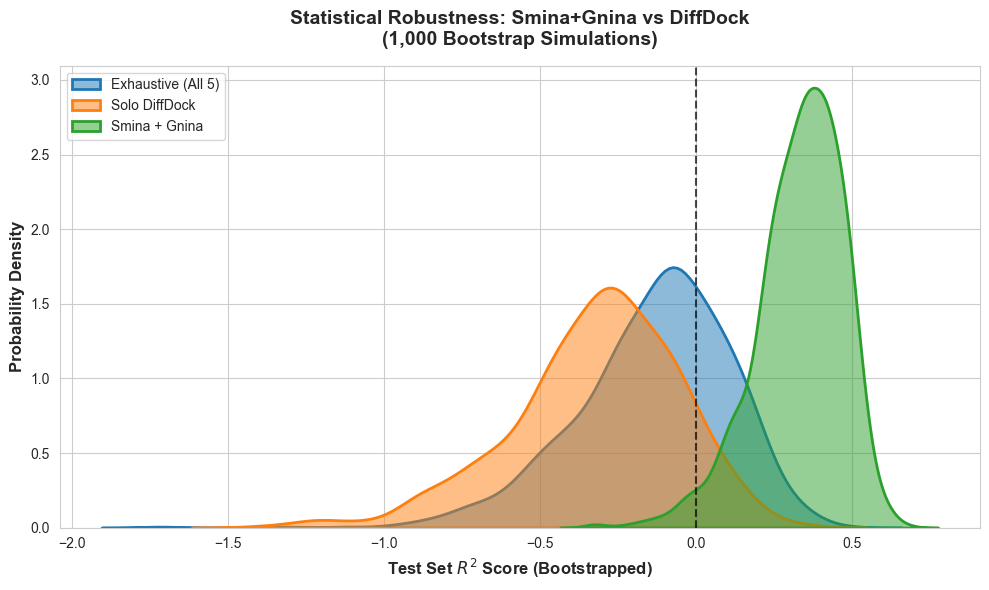

In [20]:
# ==========================================
# FINAL SECTION: 1,000-ITERATION BOOTSTRAP TEST
# ==========================================
from sklearn.utils import resample
import numpy as np
from sklearn.preprocessing import RobustScaler

print("\n" + "="*80)
print("🚀 INITIATING 1,000-ITERATION BOOTSTRAP STATISTICAL TEST")
print("="*80)

# 1. Prepare the Data (Worst-Case Imputation Baseline)
df_clean = df_matrix.copy()
feature_cols = [c for c in df_clean.columns if c not in meta_cols]
df_clean[feature_cols] = df_clean[feature_cols].fillna(df_clean[feature_cols].max())
df_clean = df_clean.dropna(subset=['true_value'])

X = df_clean[feature_cols].copy()
y = df_clean['true_value'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

scaler = RobustScaler()
X_train[feature_cols] = pd.DataFrame(scaler.fit_transform(X_train[feature_cols]), columns=feature_cols, index=X_train.index)
X_test[feature_cols] = pd.DataFrame(scaler.transform(X_test[feature_cols]), columns=feature_cols, index=X_test.index)

# 2. The Pipelines to Battle
pipelines_to_test = {
    "Exhaustive (All 5)": ["diffdock", "gnina", "smina", "plants", "flexx"],
    "Solo DiffDock": ["diffdock"],
    "Smina + Gnina": ["smina", "gnina"]
}

bootstrap_iterations = 1000
results_dist = {name: [] for name in pipelines_to_test.keys()}

print(f"Training models and running {bootstrap_iterations} simulations per pipeline...\n")

# 3. Train Models and Bootstrap Evaluation
for pipe_name, tools in pipelines_to_test.items():
    active_features = [f for f in feature_cols if get_base_tool(f) in tools]
    
    # Train ONCE on the stable training set
    model = xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6, 
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    )
    model.fit(X_train[active_features], y_train)
    
    # Predict the whole test set ONCE
    test_predictions = model.predict(X_test[active_features])
    
    # Bootstrap the evaluation 1,000 times
    for i in range(bootstrap_iterations):
        # Randomly sample the test predictions and true values with replacement
        indices = resample(np.arange(len(y_test)), replace=True, random_state=i)
        
        y_test_boot = y_test.iloc[indices]
        pred_boot = test_predictions[indices]
        
        # Calculate R2 for this specific random iteration
        score = r2_score(y_test_boot, pred_boot)
        results_dist[pipe_name].append(score)

# 4. Calculate 95% Confidence Intervals
print("================================================================")
print("🛡️ 95% CONFIDENCE INTERVALS (1,000 BOOTSTRAPS) 🛡️")
print("================================================================")

for pipe_name, scores in results_dist.items():
    scores = np.array(scores)
    mean_r2 = np.mean(scores)
    lower_bound = np.percentile(scores, 2.5)   # Bottom 2.5%
    upper_bound = np.percentile(scores, 97.5)  # Top 97.5%
    
    print(f"Pipeline: {pipe_name:<20}")
    print(f"  Mean R²:  {mean_r2:.4f}")
    print(f"  95% CI:   [{lower_bound:.4f}  to  {upper_bound:.4f}]\n")

# 5. Visualizing the Overlap (The Final Proof)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

for pipe_name, scores in results_dist.items():
    sns.kdeplot(scores, fill=True, label=pipe_name, linewidth=2, alpha=0.5)

plt.axvline(x=0.0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.xlabel("Test Set $R^2$ Score (Bootstrapped)", fontsize=12, fontweight='bold')
plt.ylabel("Probability Density", fontsize=12, fontweight='bold')
plt.title("Statistical Robustness: Smina+Gnina vs DiffDock\n(1,000 Bootstrap Simulations)", fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import r2_score
from sklearn.preprocessing import RobustScaler

print("\n" + "="*80)
print("🛡️ INITIATING ISOLATED MODEL 50-SPLIT CROSS VALIDATION 🛡️")
print("="*80)

# 1. PREPARE THE DATA (Worst-Case Imputation)
df_clean = df_matrix.copy()
feature_cols = [c for c in df_clean.columns if c not in ['true_value', 'activity_class']]

df_clean[feature_cols] = df_clean[feature_cols].fillna(df_clean[feature_cols].min())
df_clean = df_clean.dropna(subset=['true_value'])

X = df_clean[feature_cols]
y = df_clean['true_value']

# 2. DEFINE THE ISOLATED PIPELINES
pipelines = {
    "Isolated Model A (Solo DiffDock)": ["diffdock"],
    "Isolated Model B (DiffDock + Plants)": ["diffdock", "plants"],
    "Isolated Model C (Smina + Gnina)": ["smina", "gnina"]
}

rkf = RepeatedKFold(n_splits=2, n_repeats=10, random_state=42)
results = []

print("Training isolated XGBoost models with YOUR exact hyperparameters...\n")

for pipe_name, tools in pipelines.items():
    # EXPLICIT FEATURE ISOLATION: 
    # Grab ONLY the columns belonging to the tools in this specific pipeline
    isolated_features = [f for f in feature_cols if f.split('_')[0].lower() in tools]
    
    fold_scores = []
    
    # Run the 50 splits
    for train_idx, test_idx in rkf.split(X):
        # The model ONLY sees the isolated features
        X_train = X.iloc[train_idx][isolated_features]
        X_test = X.iloc[test_idx][isolated_features]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        
        # Scale locally to prevent data leakage
        scaler = MinMaxScaler()
        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=isolated_features)
        X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=isolated_features)
        
        # YOUR EXACT HYPERPARAMETERS
        model = xgb.XGBRegressor(
            n_estimators=300, 
            learning_rate=0.05, 
            max_depth=6, 
            subsample=0.8, 
            colsample_bytree=0.8, 
            random_state=42, 
            n_jobs=-1
        )
        
        # Train and Predict
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        
        fold_scores.append(r2_score(y_test, pred))
        
    # Calculate the hard statistics across all 50 realities
    scores = np.array(fold_scores)
    mean_r2 = np.mean(scores)
    std_r2 = np.std(scores)
    lower_95 = np.percentile(scores, 2.5)
    upper_95 = np.percentile(scores, 97.5)
    
    results.append({
        "Pipeline": pipe_name,
        "Features_Used": len(isolated_features),
        "Mean_R2": round(mean_r2, 4),
        "Risk_Variance (Std)": round(std_r2, 4),
        "Worst_Case_Fold": round(np.min(scores), 4),
        "Best_Case_Fold": round(np.max(scores), 4)
    })

# 3. DISPLAY THE ABSOLUTE TRUTH
df_results = pd.DataFrame(results).sort_values(by="Mean_R2", ascending=False)
print("=========================================================================================")
print("🏆 FINAL EMPIRICAL TRUTH: ISOLATED MODEL PERFORMANCE ACROSS 50 SHUFFLED REALITIES 🏆")
print("=========================================================================================")
print(df_results.to_string(index=False))


🛡️ INITIATING ISOLATED MODEL 50-SPLIT CROSS VALIDATION 🛡️
Training isolated XGBoost models with YOUR exact hyperparameters...

🏆 FINAL EMPIRICAL TRUTH: ISOLATED MODEL PERFORMANCE ACROSS 50 SHUFFLED REALITIES 🏆
                            Pipeline  Features_Used  Mean_R2  Risk_Variance (Std)  Worst_Case_Fold  Best_Case_Fold
Isolated Model B (DiffDock + Plants)             20   0.1100               0.0738          -0.0274          0.2325
    Isolated Model A (Solo DiffDock)             10   0.0983               0.0725          -0.0458          0.1957
    Isolated Model C (Smina + Gnina)             20  -0.0718               0.1186          -0.3113          0.1764


In [17]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("🧬 INITIATING PIPELINE V2.1: NON-LINEAR BENCHMARK (LOOCV)")
print("="*80)

# 1. PREPARE THE DATA (Returning to the scientifically proven MAX Imputation)
df_clean = df_matrix.copy()
feature_cols = [c for c in df_clean.columns if c not in ['true_value', 'activity_class']]

# Punish crashes with the maximum (worst) possible score
df_clean[feature_cols] = df_clean[feature_cols].fillna(df_clean[feature_cols].max())
df_clean = df_clean.dropna(subset=['true_value'])

X = df_clean[feature_cols].copy()
y = df_clean['true_value'].copy()

# 2. DEFINE THE NON-LINEAR MODELS
models = {
    "Support Vector Regression (RBF)": SVR(kernel='rbf', C=10.0, epsilon=0.1),
    "Random Forest (Stable Trees)": RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1),
    "XGBoost (Gradient Trees)": xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42, n_jobs=-1)
}

loo = LeaveOneOut()
results = []

print(f"Running strict LOOCV on {len(X)} molecules. Testing 3 different non-linear brains...\n")

for model_name, model in models.items():
    y_true = []
    y_pred = []
    
    for train_index, test_index in loo.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # Robust Scaling (Fitted only on train to prevent leakage)
        scaler = RobustScaler()
        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
        X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)
        
        # Train and Predict
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        
        # SVR outputs a 1D array, XGBoost outputs an array of arrays. Safely extract the float:
        try:
            pred_val = float(pred.ravel()[0])
        except:
            pred_val = float(pred[0])
            
        y_pred.append(pred_val)
        y_true.append(y_test.values[0])
        
    # Calculate unbiased metrics
    r2 = r2_score(y_true, y_pred)
    pearson, _ = pearsonr(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    results.append({
        "Model Architecture": model_name,
        "True Pearson r": round(pearson, 4),
        "True R² Score": round(r2, 4),
        "RMSE Error": round(rmse, 4)
    })

# 3. DISPLAY RESULTS
df_results = pd.DataFrame(results).sort_values(by="True R² Score", ascending=False)
print("=======================================================================")
print("🏆 LEAVE-ONE-OUT VALIDATION: NON-LINEAR ARCHITECTURE RESULTS 🏆")
print("=======================================================================")
print(df_results.to_string(index=False))


🧬 INITIATING PIPELINE V2.1: NON-LINEAR BENCHMARK (LOOCV)
Running strict LOOCV on 201 molecules. Testing 3 different non-linear brains...

🏆 LEAVE-ONE-OUT VALIDATION: NON-LINEAR ARCHITECTURE RESULTS 🏆
             Model Architecture  True Pearson r  True R² Score  RMSE Error
   Random Forest (Stable Trees)          0.5207         0.2682      1.2555
       XGBoost (Gradient Trees)          0.4795         0.2113      1.3034
Support Vector Regression (RBF)         -0.1671        -0.0530      1.5060


In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb
import itertools
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("🚀 FAST EXHAUSTIVE SEARCH: EXACT COST & NATIVE NaN XGBOOST")
print("="*80)

# 1. THE EXACT COST DICTIONARY
_cost = {
    "localdiffdock": 407.5, "diffdock": 407.5, "flexx": 3.33, "smina": 99.9,
    "gnina": 105.8, "plants": 6.85, "cnnscore": 0.31, "cnnaffinity": 0.31,
    "smina_affinity": 0.31, "ad4": 0.28, "linf9": 0.24, "rtmscore": 0.41,
    "vinardo": 0.29, "scorch": 4.63, "hyde": 2.0, "chemplp": 0.121,
    "rfscore_v1": 0.682, "rfscore_v2": 0.687, "rfscore_v3": 0.69,
    "vina_hydrophobic": 0.69, "vina_intra_hydrophobic": 0.69,
}

# 2. PREPARE THE RAW DATA (NO IMPUTATION, NO SCALING)
df_clean = df_matrix.copy()
# Only drop rows where the target we are trying to predict is missing
df_clean = df_clean.dropna(subset=['true_value'])

feature_cols = [c for c in df_clean.columns if c not in ['true_value', 'activity_class']]
X = df_clean[feature_cols]
y = df_clean['true_value']

# 3. EXACT COST CALCULATOR FUNCTION
def calculate_exact_cost(active_features):
    total_cost = 0.0
    base_tools_used = set()
    
    for feature in active_features:
        # Example feature: 'diffdock_vina_intra_hydrophobic'
        parts = feature.lower().split('_', 1)
        base_tool = parts[0]
        scoring_func = parts[1] if len(parts) > 1 else ""
        
        # Add base tool to set (so we only charge it once)
        base_tools_used.add(base_tool)
        
        # Charge for the specific scoring function
        if scoring_func in _cost:
            total_cost += _cost[scoring_func]
            
    # Add base tool costs
    for tool in base_tools_used:
        if tool in _cost:
            total_cost += _cost[tool]
            
    return total_cost

# 4. BRUTE FORCE ALL 31 COMBINATIONS
base_tools = ['diffdock', 'flexx', 'gnina', 'plants', 'smina']
all_combinations = []
for i in range(1, len(base_tools) + 1):
    all_combinations.extend(itertools.combinations(base_tools, i))

results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Evaluating all 31 base-tool pipelines using 5-Fold CV (155 total models)...")

for combo in all_combinations:
    combo_list = list(combo)
    
    # Extract only features belonging to the selected base tools
    active_features = [f for f in feature_cols if f.split('_')[0].lower() in combo_list]
    
    if len(active_features) == 0:
        continue
        
    pipeline_cost = calculate_exact_cost(active_features)
    
    fold_r2 = []
    
    for train_idx, val_idx in kf.split(X):
        # Slice data
        X_train, X_val = X.iloc[train_idx][active_features], X.iloc[val_idx][active_features]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Static, stable XGBoost parameters (Native NaN handling via missing=np.nan)
        model = xgb.XGBRegressor(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            missing=np.nan
        )
        
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        fold_r2.append(r2_score(y_val, preds))
        
    results.append({
        "Pipeline": ", ".join(combo_list),
        "Total Cost (s)": round(pipeline_cost, 2),
        "Mean R²": round(np.mean(fold_r2), 4),
        "Risk (Std)": round(np.std(fold_r2), 4)
    })

# 5. EXTRACT PARETO FRONTIER & DISPLAY
df_all = pd.DataFrame(results).sort_values(by='Total Cost (s)', ascending=True)

pareto_frontier = []
max_r2_seen = -float('inf')

for _, row in df_all.iterrows():
    if row['Mean R²'] > max_r2_seen:
        pareto_frontier.append(row)
        max_r2_seen = row['Mean R²']

df_pareto = pd.DataFrame(pareto_frontier).sort_values(by='Total Cost (s)', ascending=True)

print("\n" + "="*80)
print("🏆 THE EXACT PARETO FRONTIER (COST VS ACCURACY) 🏆")
print("="*80)
print(df_pareto.to_string(index=False))

print("\n" + "="*80)
print("📋 FULL ANALYSIS LOG: ALL 31 COMBINATIONS 📋")
print("="*80)
print(df_all.to_string(index=False))


🚀 FAST EXHAUSTIVE SEARCH: EXACT COST & NATIVE NaN XGBOOST
Evaluating all 31 base-tool pipelines using 5-Fold CV (155 total models)...

🏆 THE EXACT PARETO FRONTIER (COST VS ACCURACY) 🏆
       Pipeline  Total Cost (s)  Mean R²  Risk (Std)
          flexx           13.49  -0.3052      0.3779
         plants           17.01  -0.0452      0.1019
          smina          110.06   0.0655      0.1927
       diffdock          417.66   0.1535      0.1755
diffdock, smina          527.72   0.1692      0.1480

📋 FULL ANALYSIS LOG: ALL 31 COMBINATIONS 📋
                             Pipeline  Total Cost (s)  Mean R²  Risk (Std)
                                flexx           13.49  -0.3052      0.3779
                               plants           17.01  -0.0452      0.1019
                        flexx, plants           30.50  -0.1084      0.2256
                                smina          110.06   0.0655      0.1927
                                gnina          115.96  -0.0640      0.2943
   